# Refusal Ablation — Demo

Orchestration notebook for the `refusal-ablation` repo. All logic lives in `src/` — this notebook just wires it together for a given config, so results are reproducible from code, not from notebook-only cells.


## Setup: clone the repo (for Colab) and install deps

In [1]:
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone -q https://github.com/FarrahTharwat/refusal-ablation.git
    %cd refusal-ablation
    !pip install -q datasets pyyaml
else:
    # Local Jupyter: if this notebook is opened from notebooks/, walk up
    # to the repo root (the directory that actually contains src/).
    cwd = os.getcwd()
    if os.path.basename(cwd) == "notebooks" and os.path.isdir(os.path.join(cwd, "..", "src")):
        os.chdir("..")
    assert os.path.isdir("src"), (
        f"Can't find src/ from {os.getcwd()} — open this notebook from the repo root, "
        "or from notebooks/ inside it."
    )

sys.path.insert(0, os.getcwd())
print("working dir:", os.getcwd())


/content/refusal-ablation
working dir: /content/refusal-ablation


## Load config and model

In [2]:
import yaml
import torch

from src.data import build_splits
from src.metrics import filter_refused, refusal_rate
from src.model_utils import load_model
from src.extract_direction import select_layer, extract_direction
from src.sweep import run_alpha_sweep, run_beta_sweep, save_results

CONFIG_PATH = "configs/qwen1.5-1.8b.yaml"   # swap this to try a different model
cfg = yaml.safe_load(open(CONFIG_PATH))
model_alias = cfg["model_name"].split("/")[-1]

torch.manual_seed(cfg["seed"])
model, tok = load_model(cfg)
print(f"{cfg['model_name']} loaded, {len(model.model.layers)} layers")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.67GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

Qwen/Qwen1.5-1.8B-Chat loaded, 24 layers


## Build data splits (extraction set + disjoint held-out eval set)

In [3]:
harmful_extract_pool, harmful_eval_pool, harmless_extract_pool, harmless_eval_pool = build_splits(cfg)

harmful_extract = filter_refused(model, tok, harmful_extract_pool)
harmless_extract = harmless_extract_pool[:len(harmful_extract)]
print(f"{len(harmful_extract)} harmful extraction prompts survived the refusal filter")

harmful_eval = filter_refused(model, tok, harmful_eval_pool)[: cfg["eval_n"]]
harmless_eval = harmless_eval_pool[: len(harmful_eval)]
print(f"held-out eval sets: {len(harmful_eval)} harmful, {len(harmless_eval)} harmless")


README.md:   0%|          | 0.00/7.47k [00:00<?, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…): reconstructing file:   0%|          |  0.00B / 24.2MB            

data/train-00000-of-00001-a09b74b3ef9c3b(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

25 harmful extraction prompts survived the refusal filter
held-out eval sets: 40 harmful, 40 harmless


## Select the best layer, then extract the final direction

In [4]:
best_layer, layer_scores = select_layer(model, tok, cfg, harmful_extract, harmless_extract, harmful_eval)
direction = extract_direction(model, tok, harmful_extract, harmless_extract, best_layer)
ADD_LAYER = best_layer


layer  4: refusal rate under full ablation = 1.00
layer  5: refusal rate under full ablation = 0.75
layer  6: refusal rate under full ablation = 0.81
layer  7: refusal rate under full ablation = 1.00
layer  8: refusal rate under full ablation = 0.94
layer  9: refusal rate under full ablation = 0.38
layer 10: refusal rate under full ablation = 0.62
layer 11: refusal rate under full ablation = 0.19
layer 12: refusal rate under full ablation = 0.19
layer 13: refusal rate under full ablation = 0.00
layer 14: refusal rate under full ablation = 0.00
layer 15: refusal rate under full ablation = 0.06
layer 16: refusal rate under full ablation = 0.00
layer 17: refusal rate under full ablation = 0.00
layer 18: refusal rate under full ablation = 0.06
layer 19: refusal rate under full ablation = 0.06
layer 20: refusal rate under full ablation = 0.25
layer 21: refusal rate under full ablation = 0.06
layer 22: refusal rate under full ablation = 0.31
layer 23: refusal rate under full ablation = 0.31


## Baseline sanity check

In [5]:
baseline_harmful_rr = refusal_rate(model, tok, harmful_eval)
baseline_harmless_rr = refusal_rate(model, tok, harmless_eval)
print(f"baseline harmful refusal rate:  {baseline_harmful_rr:.2f}")
print(f"baseline harmless refusal rate: {baseline_harmless_rr:.2f}")


baseline harmful refusal rate:  1.00
baseline harmless refusal rate: 0.03


## Alpha/beta sweep — the headline artifact

alpha=0.00  harmful_rr=1.00  harmless_rr=0.03
alpha=0.25  harmful_rr=0.15  harmless_rr=0.03
alpha=0.50  harmful_rr=0.00  harmless_rr=0.03
alpha=0.75  harmful_rr=0.00  harmless_rr=0.03
alpha=1.00  harmful_rr=0.00  harmless_rr=0.03
alpha=1.25  harmful_rr=0.00  harmless_rr=0.03
alpha=1.50  harmful_rr=0.00  harmless_rr=0.03
beta=0.00  harmful_rr=1.00  harmless_rr=0.03
beta=1.00  harmful_rr=1.00  harmless_rr=0.03
beta=2.00  harmful_rr=1.00  harmless_rr=0.03
beta=4.00  harmful_rr=1.00  harmless_rr=0.03
beta=6.00  harmful_rr=1.00  harmless_rr=0.05
beta=8.00  harmful_rr=1.00  harmless_rr=0.10
beta=10.00  harmful_rr=1.00  harmless_rr=0.15
beta=12.00  harmful_rr=1.00  harmless_rr=0.28


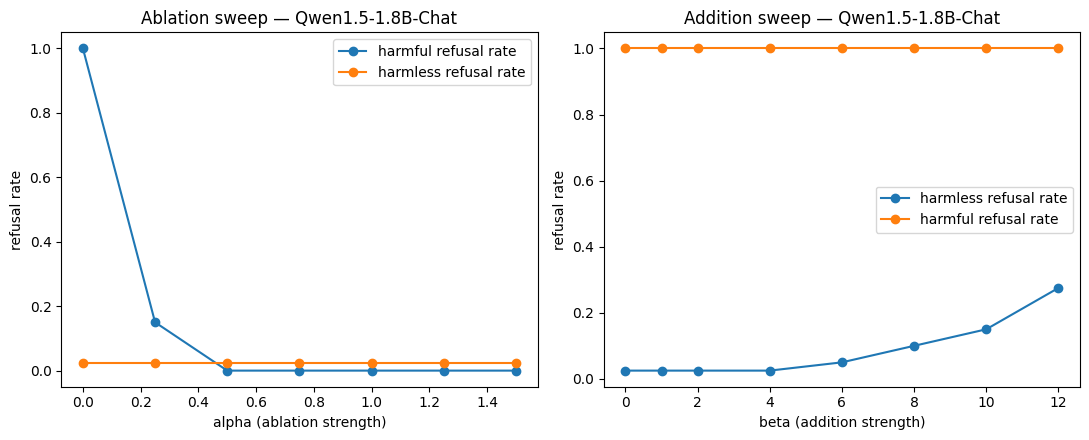

saved: results/alpha_sweep_Qwen1.5-1.8B-Chat.csv, results/beta_sweep_Qwen1.5-1.8B-Chat.csv, results/crossover_Qwen1.5-1.8B-Chat.png


('results/alpha_sweep_Qwen1.5-1.8B-Chat.csv',
 'results/beta_sweep_Qwen1.5-1.8B-Chat.csv',
 'results/crossover_Qwen1.5-1.8B-Chat.png')

In [6]:
alpha_df = run_alpha_sweep(model, tok, direction, ADD_LAYER, harmful_eval, harmless_eval, cfg["alphas"])
beta_df = run_beta_sweep(model, tok, direction, ADD_LAYER, harmful_eval, harmless_eval, cfg["betas"])
save_results(alpha_df, beta_df, results_dir="results", model_alias=model_alias)
